In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Dados-modelo/df_preliminar.csv', sep=';')

In [4]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'ACESSO_LOCAL', 'MULTIPLO_PESA', 'REGIAO',
       'PESA', 'MUNI_REFERENCIADO', 'OBSERVACOES', 'LAT_MUNI', 'LON_MUNI',
       'LAT_PESA', 'LON_PESA', 'DISTANCIA', 'TEMPO', 'IBGE', 'MUNI_NOME_x',
       'POP10', 'POP12', 'POP11A59', 'POP60', 'POP_GERAL', 'MACRO_CODIGO',
       'MACRO_NOME', 'DRS_CODIGO', 'DRS_NOME', 'CIR_CODIGO', 'CIR_NOME',
       'TOTAL_CASOS', 'TOTAL_10A', 'TOTAL_12A', 'TOTAL_11A59', 'TOTAL_60',
       'LEVE', 'MG', 'MG_ORIGINAL', 'LEVE_10', 'MG_10', 'LEVE_12', 'MG_12',
       'LEVE_11A59', 'MG_11A59', 'LEVE_60', 'MG_60', 'TOTAL_AMPOLAS',
       'CAT_TEMPO', 'PROP_POP_0A10', 'PROP_POP_60MAIS', 'LOG_POP', 'PROP_MG',
       'INCID_MEDIA_GERAL', 'INCID_0A10', 'INCID_60MAIS', 'PROP_CASOS_0A10',
       'PROP_CASOS_60MAIS', 'TAXA_MG_100MIL', 'CLASS_IG', 'SORO_IG', 'EVOL_IG',
       'PROP_CLASS_IGN', 'PROP_SORO_IGN', 'PROP_EVOL_IGN', 'BAIXO_N'],
      dtype='str')

## Caracterização geral

In [5]:
print(
    '========== DADOS GERAIS ==========\n'
    f'Total de municípios: {len(df)}\n'
    f'Total de casos: {df["TOTAL_CASOS"].sum():,.0f}\n'
    f'Total de casos leves: {df["LEVE"].sum():,.0f}\n'
    f'Total de casos MG: {df["MG"].sum():,.0f}\n'
    f'Proporção de MG: {100*df["MG"].sum()/df["TOTAL_CASOS"].sum():.2f}%\n'
    '\n'
    '========== FAIXA ETÁRIA ==========\n'
    f'Total <10 anos: {(df["LEVE_10"] + df["MG_10"]).sum():,.0f}\n'
    f'Casos MG <10 anos: {df["MG_10"].sum():,.0f}\n'
    f'Proporção MG <10 anos: {100*df["MG_10"].sum()/(df["LEVE_10"] + df["MG_10"]).sum():.2f}%\n'
    '\n'
    f'Total ≥60 anos: {(df["LEVE_60"] + df["MG_60"]).sum():,.0f}\n'
    f'Casos MG ≥60 anos: {df["MG_60"].sum():,.0f}\n'
    f'Proporção MG ≥60 anos: {100*df["MG_60"].sum()/(df["LEVE_60"] + df["MG_60"]).sum():.2f}%'
)

========== DADOS GERAIS ==========
Total de municípios: 645
Total de casos: 117,356
Total de casos leves: 109,704
Total de casos MG: 7,652
Proporção de MG: 6.52%

========== FAIXA ETÁRIA ==========
Total <10 anos: 10,673
Casos MG <10 anos: 2,689
Proporção MG <10 anos: 25.19%

Total ≥60 anos: 21,646
Casos MG ≥60 anos: 937
Proporção MG ≥60 anos: 4.33%


In [6]:
print(
    '\n========== ACESSO AO PESA ==========\n'
    f'Municípios: {len(df)}\n'
    f'Com PESA local: {(df["TEMPO"]==0).sum()}\n'
    f'Sem PESA local: {(df["TEMPO"]>0).sum()}\n'
    f'% com PESA local: {100*(df["TEMPO"]==0).mean():.1f}%'
)


========== ACESSO AO PESA ==========
Municípios: 645
Com PESA local: 202
Sem PESA local: 443
% com PESA local: 31.3%


In [7]:
print(
    '\n========== MUNICÍPIOS COM MG ==========\n'
    f'Municípios com pelo menos 1 MG: {(df["MG"]>0).sum()}\n'
    f'Municípios sem MG: {(df["MG"]==0).sum()}\n'
    f'% sem MG: {100*(df["MG"]==0).mean():.1f}%'
)


========== MUNICÍPIOS COM MG ==========
Municípios com pelo menos 1 MG: 543
Municípios sem MG: 102
% sem MG: 15.8%


In [8]:
# Resumo estatístico das variáveis contínuas

variaveis = [
    'TEMPO',
    'DISTANCIA',
    'INCID_MEDIA_GERAL',
    'PROP_MG',
    'PROP_CASOS_0A10',
    'PROP_CASOS_60MAIS'
]

resumo = (
    df[variaveis]
    .describe(percentiles=[0.05,0.10,0.25,0.50,0.75,0.90,0.95])
    .T
)

resumo = resumo.rename(columns={
    'count':'N',
    'mean':'Média',
    'std':'DP',
    'min':'Mínimo',
    '5%':'P5',
    '10%':'P10',
    '25%':'Q1',
    '50%':'Mediana',
    '75%':'Q3',
    '90%':'P90',
    '95%':'P95',
    'max':'Máximo'
})

display(resumo.round(2))

,N,Média,DP,Mínimo,P5,P10,Q1,Mediana,Q3,P90,P95,Máximo
TEMPO,645.0,18.91,16.19,0.0,0.00,0.0,0.00,19.50,29.00,40.96,47.32,70.80
DISTANCIA,645.0,18.81,16.99,0.0,0.00,0.0,0.00,18.10,30.00,41.16,50.20,84.40
INCID_MEDIA_GERAL,645.0,167.22,203.71,0.0,1.17,4.0,20.86,87.82,236.00,473.83,635.46,1084.77
PROP_MG,645.0,0.10,0.14,0.0,0.00,0.0,0.03,0.06,0.12,0.24,0.33,1.00
PROP_CASOS_0A10,645.0,0.10,0.11,0.0,0.00,0.0,0.05,0.08,0.12,0.18,0.26,1.00
PROP_CASOS_60MAIS,645.0,0.16,0.11,0.0,0.00,0.0,0.10,0.17,0.22,0.27,0.33,1.00


In [9]:
# Assimetria
print(df[variaveis].skew().round(2))
'''Regra prática:

|Skew| < 0,5 → aproximadamente simétrica
0,5–1 → moderadamente assimétrica

1 → bastante assimétrica

Isso já indica se faz sentido usar média ou mediana.'''

TEMPO                0.43
DISTANCIA            0.68
INCID_MEDIA_GERAL    1.77
PROP_MG              3.60
PROP_CASOS_0A10      4.16
PROP_CASOS_60MAIS    1.67
dtype: float64


'Regra prática:\n\n|Skew| < 0,5 → aproximadamente simétrica\n0,5–1 → moderadamente assimétrica\n\n1 → bastante assimétrica\n\nIsso já indica se faz sentido usar média ou mediana.'

In [10]:
# Coeficiente de variação


cv = (
    df[variaveis].std() /
    df[variaveis].mean()
)*100

display(cv.round(1))


'''Ajuda a entender a dispersão relativa.
O valor percentual mostra o tamanho do desvio em comparação com a média:
Até 15%: Baixa dispersão (dados homogêneos, muito próximos da média).
Entre 15% e 30%: Dispersão média.
Acima de 30%: Alta dispersão (dados heterogêneos, espalhados).

Comparação: Permite comparar a dispersão de dois grupos com unidades de medida diferentes ou médias muito distantes 
(por exemplo, comparar a variação de peso em quilos de elefantes versus camundongos).
Homogeneidade: Quanto menor o CV, mais uniforme e confiável é o conjunto de dados.'''

TEMPO                 85.6
DISTANCIA             90.3
INCID_MEDIA_GERAL    121.8
PROP_MG              135.7
PROP_CASOS_0A10      108.5
PROP_CASOS_60MAIS     65.9
dtype: float64

'Ajuda a entender a dispersão relativa.\nO valor percentual mostra o tamanho do desvio em comparação com a média:\nAté 15%: Baixa dispersão (dados homogêneos, muito próximos da média).\nEntre 15% e 30%: Dispersão média.\nAcima de 30%: Alta dispersão (dados heterogêneos, espalhados).\n\nComparação: Permite comparar a dispersão de dois grupos com unidades de medida diferentes ou médias muito distantes \n(por exemplo, comparar a variação de peso em quilos de elefantes versus camundongos).\nHomogeneidade: Quanto menor o CV, mais uniforme e confiável é o conjunto de dados.'

In [11]:
# Percentual de municipios sem MG
print(
    f'Municípios com MG=0: {(df.MG==0).sum()} ({((df.MG==0).sum()/df.MG.size*100).round(2)}%)',
    '\n',
    f'Municípios com MG>0: {(df.MG>0).sum()} ({((df.MG>0).sum()/df.MG.size*100).round(2)}%)',
)


Municípios com MG=0: 102 (15.81%) 
 Municípios com MG>0: 543 (84.19%)


In [12]:
# Faixas de casos
bins = [0,5,10,20,50,100,1000]

faixas = pd.cut(
    df['TOTAL_CASOS'],
    bins=bins
)

display(
    faixas.value_counts().sort_index()
)

TOTAL_CASOS
(0, 5]          66
(5, 10]         47
(10, 20]        54
(20, 50]       129
(50, 100]      119
(100, 1000]    198
Name: count, dtype: int64

In [13]:
# Outliers
for v in ['TEMPO','DISTANCIA','PROP_MG','INCID_MEDIA_GERAL']:

    print('\n',v)

    print(df.nlargest(10,v)[['MUNI_REFERENCIADO',v]])



 TEMPO
          MUNI_REFERENCIADO  TEMPO
141                PIRACAIA  70.80
392     NATIVIDADE DA SERRA  63.70
117               PORANGABA  63.50
429               UBIRAJARA  61.65
328                  IRAPUA  60.70
162  BOM SUCESSO DE ITARARE  60.20
165                 RIBEIRA  59.10
123          TORRE DE PEDRA  58.20
344          PAULO DE FARIA  57.90
67                JABORANDI  57.60

 DISTANCIA
          MUNI_REFERENCIADO  DISTANCIA
117               PORANGABA  84.400000
123          TORRE DE PEDRA  76.000000
67                JABORANDI  74.000000
141                PIRACAIA  71.000000
101                     URU  70.500000
344          PAULO DE FARIA  68.100000
421                GUARANTA  63.106452
63                  TIMBURI  62.900000
162  BOM SUCESSO DE ITARARE  62.200000
415   CAMPOS NOVOS PAULISTA  61.928571

 PROP_MG
           MUNI_REFERENCIADO  PROP_MG
164             NOVA CAMPINA     1.00
165                  RIBEIRA     1.00
398  SANTO ANTONIO DO PINHAL     1.00
535 

In [14]:
# Total de casos por municipio
df['TOTAL_CASOS_MUNICIPIO'] = df['MG'] + df['LEVE']

display(
    df['TOTAL_CASOS_MUNICIPIO'].describe(
        percentiles=[0.25,0.5,0.75,0.9,0.95]
    )
)

'''Ela permitirá responder perguntas como:

Qual o número mediano de acidentes por município?
Quantos municípios tiveram menos de cinco casos?
O banco é dominado por municípios pequenos?'''

count     645.000000
mean      181.947287
std       413.917128
min         0.000000
25%        17.000000
50%        57.000000
75%       158.000000
90%       435.200000
95%       730.800000
max      5555.000000
Name: TOTAL_CASOS_MUNICIPIO, dtype: float64

'Ela permitirá responder perguntas como:\n\nQual o número mediano de acidentes por município?\nQuantos municípios tiveram menos de cinco casos?\nO banco é dominado por municípios pequenos?'

In [16]:
# Listar extremos

display(
df.nlargest(20, 'PROP_MG')['MUNI_REFERENCIADO'],

df.nlargest(20, 'TEMPO')['MUNI_REFERENCIADO'],

df.nlargest(20, 'INCID_MEDIA_GERAL')['MUNI_REFERENCIADO']
)

164               NOVA CAMPINA
165                    RIBEIRA
398    SANTO ANTONIO DO PINHAL
535                JACUPIRANGA
540                SETE BARRAS
592                      APIAI
549                   BERTIOGA
556                     SANTOS
294                    SERRANA
112                 ITAPORANGA
121                     TAGUAI
584                   ANGATUBA
66                     GUARACI
162     BOM SUCESSO DE ITARARE
292                  SAO SIMAO
299        RIO GRANDE DA SERRA
306               DIVINOLANDIA
543                     CAJURU
586               ITAPETININGA
555               PRAIA GRANDE
Name: MUNI_REFERENCIADO, dtype: str

141                  PIRACAIA
392       NATIVIDADE DA SERRA
117                 PORANGABA
429                 UBIRAJARA
328                    IRAPUA
162    BOM SUCESSO DE ITARARE
165                   RIBEIRA
123            TORRE DE PEDRA
344            PAULO DE FARIA
67                  JABORANDI
63                    TIMBURI
326            GASTAO VIDIGAL
101                       URU
421                  GUARANTA
330                  MACAUBAL
103                   ANHEMBI
31                    DOURADO
166                  RIVERSUL
415     CAMPOS NOVOS PAULISTA
417                    FERNAO
Name: MUNI_REFERENCIADO, dtype: str

174                  INDIAPORA
15            MURUTINGA DO SUL
246       SANTA MARIA DA SERRA
447                   GUARACAI
270              MONTE CASTELO
632              MIRASSOLANDIA
641                 ONDA VERDE
315           ALVARES FLORENCE
179               MIRA ESTRELA
582                   OUROESTE
340                  PALESTINA
2                      BARBOSA
520    MIRANTE DO PARANAPANEMA
450               MIRANDOPOLIS
273                  PAULICEIA
343                     PARISI
183               PEDRANOPOLIS
271          NOVA GUATAPORANGA
17          NOVA INDEPENDENCIA
633                POTIRENDABA
Name: MUNI_REFERENCIADO, dtype: str

# Relações bivariadas (estatísticas) → correlações, tabelas e testes.

In [15]:
# Matriz de correlação de Spearman
vars_corr = [
    'TEMPO',
    'DISTANCIA',
    'INCID_MEDIA_GERAL',
    'PROP_MG',
    'PROP_CASOS_0A10',
    'PROP_CASOS_60MAIS'
]

corr = df[vars_corr].corr(method='spearman')

display(corr.round(3))

,TEMPO,DISTANCIA,INCID_MEDIA_GERAL,PROP_MG,PROP_CASOS_0A10,PROP_CASOS_60MAIS
TEMPO,1.000,0.987,0.170,-0.068,0.021,0.035
DISTANCIA,0.987,1.000,0.181,-0.068,0.032,0.033
INCID_MEDIA_GERAL,0.170,0.181,1.000,-0.186,0.073,0.537
PROP_MG,-0.068,-0.068,-0.186,1.000,0.254,-0.074
PROP_CASOS_0A10,0.021,0.032,0.073,0.254,1.000,-0.142
PROP_CASOS_60MAIS,0.035,0.033,0.537,-0.074,-0.142,1.000


In [ ]:
# Valores de p das correlações

from scipy.stats import spearmanr
import pandas as pd

vars_corr = [
    'TEMPO',
    'DISTANCIA',
    'INCID_MEDIA_GERAL',
    'PROP_MG',
    'PROP_CASOS_0A10',
    'PROP_CASOS_60MAIS'
]

pval = pd.DataFrame(index=vars_corr, columns=vars_corr)

for i in vars_corr:
    for j in vars_corr:
        pval.loc[i,j] = spearmanr(df[i], df[j], nan_policy='omit').pvalue

display(pval.astype(float).round(4))

,TEMPO,DISTANCIA,INCID_MEDIA_GERAL,PROP_MG,PROP_CASOS_0A10,PROP_CASOS_60MAIS
TEMPO,0.0000,0.0000,0.0000,0.0866,0.6031,0.3768
DISTANCIA,0.0000,0.0000,0.0000,0.0840,0.4214,0.3965
INCID_MEDIA_GERAL,0.0000,0.0000,0.0000,0.0000,0.0643,0.0000
PROP_MG,0.0866,0.0840,0.0000,0.0000,0.0000,0.0601
PROP_CASOS_0A10,0.6031,0.4214,0.0643,0.0000,0.0000,0.0003
PROP_CASOS_60MAIS,0.3768,0.3965,0.0000,0.0601,0.0003,0.0000


In [26]:
# Correlação apenas com PROP_MG

from scipy.stats import spearmanr

for var in [
    'TEMPO',
    'DISTANCIA',
    'INCID_MEDIA_GERAL',
    'PROP_CASOS_0A10',
    'PROP_CASOS_60MAIS'
]:

    rho, p = spearmanr(
        df[var],
        df['PROP_MG'],
        nan_policy='omit'
    )

    print(
        f'{var:25}',
        f'rho={rho:6.3f}',
        f'p={p:.4f}'
    )

TEMPO                     rho=-0.068 p=0.0866
DISTANCIA                 rho=-0.068 p=0.0840
INCID_MEDIA_GERAL         rho=-0.186 p=0.0000
PROP_CASOS_0A10           rho= 0.254 p=0.0000
PROP_CASOS_60MAIS         rho=-0.074 p=0.0601


In [28]:
# VIF (multicolinearidade)
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[
    [
        'TEMPO',
        'INCID_MEDIA_GERAL',
        'PROP_CASOS_0A10',
        'PROP_CASOS_60MAIS'
    ]
].dropna()

vif = pd.DataFrame()

vif["Variável"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

display(vif.round(2))

,Variável,VIF
0,TEMPO,1.98
1,INCID_MEDIA_GERAL,1.85
2,PROP_CASOS_0A10,1.48
3,PROP_CASOS_60MAIS,2.41


In [29]:
# Correlação ponderada
'''A correlação de Spearman trata igualmente:

município com 2 casos;
município com 300 casos.

Mas isso não parece muito razoável.

Então eu faria também uma correlação ponderada pelo número de acidentes.'''

import statsmodels.api as sm

x = df['TEMPO']
y = df['PROP_MG']
peso = df['TOTAL_CASOS']

modelo = sm.WLS(
    y,
    sm.add_constant(x),
    weights=peso
).fit()

print(modelo.summary())

                            WLS Regression Results                            
Dep. Variable:                PROP_MG   R-squared:                       0.000
Model:                            WLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.04258
Date:                qui, 30 jul 2026   Prob (F-statistic):              0.837
Time:                        21:11:35   Log-Likelihood:                   -inf
No. Observations:                 645   AIC:                               inf
Df Residuals:                     643   BIC:                               inf
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0646      0.002     27.292      0.0

/home/usuario/venvs/datascience/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:806: RuntimeWarning: divide by zero encountered in log
  llf += 0.5 * np.sum(np.log(self.weights))


In [34]:
# Correlação após excluir municípios muito pequenos
df10 = df[df['TOTAL_CASOS'] >= 20]

In [ ]:
rho, p = spearmanr(
    df10['TEMPO'],
    df10['PROP_MG']
)

print(rho, p)

'''
Repita com
>=5
>=10
>=20

Se o rho praticamente não mudar, isso fortalece muito a robustez da associação.'''

-0.09008929983122932 0.050461638394937856


# Graficos

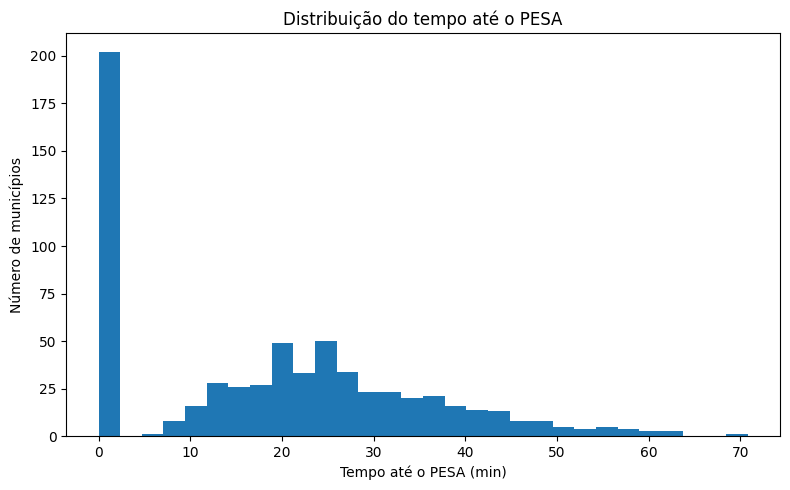

'Observe:\n\nexiste pico em 0?\ndistribuição é assimétrica?\nexistem caudas longas?'

In [42]:
# Distribuição do tempo

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["TEMPO"], bins=30)

plt.xlabel("Tempo até o PESA (min)")
plt.ylabel("Número de municípios")
plt.title("Distribuição do tempo até o PESA")

plt.tight_layout()
plt.show()


'''Observe:

existe pico em 0?
distribuição é assimétrica?
existem caudas longas?'''

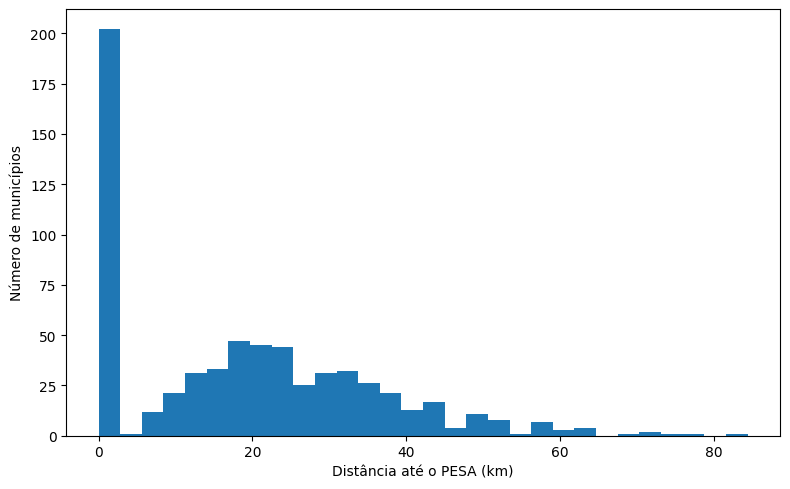

In [43]:
# Distribuição da distância

plt.figure(figsize=(8,5))

plt.hist(df["DISTANCIA"], bins=30)

plt.xlabel("Distância até o PESA (km)")
plt.ylabel("Número de municípios")

plt.tight_layout()
plt.show()

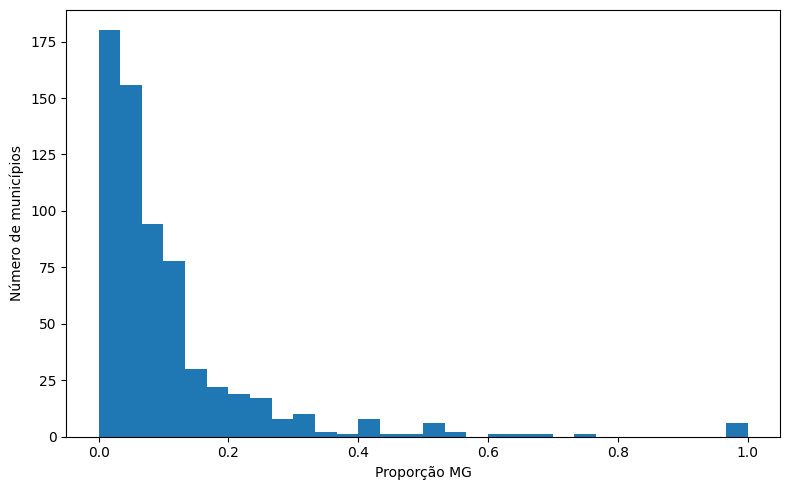

In [44]:
# Distribuição da proporção MG
plt.figure(figsize=(8,5))

plt.hist(df["PROP_MG"], bins=30)

plt.xlabel("Proporção MG")
plt.ylabel("Número de municípios")

plt.tight_layout()
plt.show()

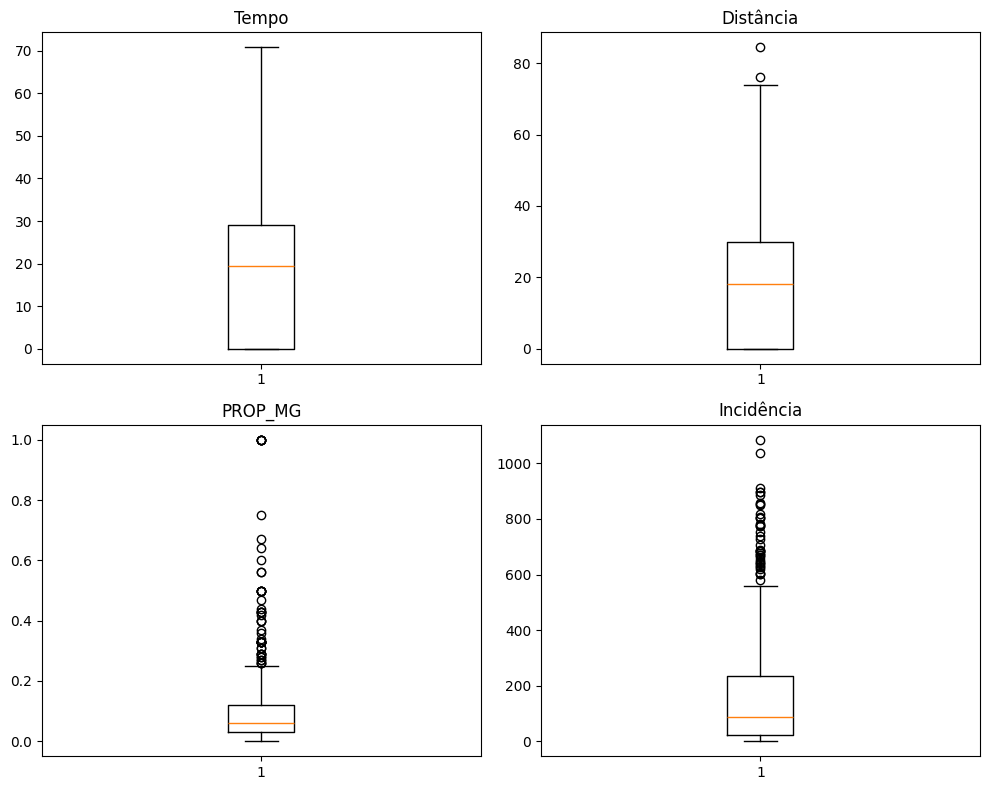

In [45]:
# Boxplots

fig, ax = plt.subplots(2,2, figsize=(10,8))

ax[0,0].boxplot(df["TEMPO"].dropna())
ax[0,0].set_title("Tempo")

ax[0,1].boxplot(df["DISTANCIA"].dropna())
ax[0,1].set_title("Distância")

ax[1,0].boxplot(df["PROP_MG"].dropna())
ax[1,0].set_title("PROP_MG")

ax[1,1].boxplot(df["INCID_MEDIA_GERAL"].dropna())
ax[1,1].set_title("Incidência")

plt.tight_layout()

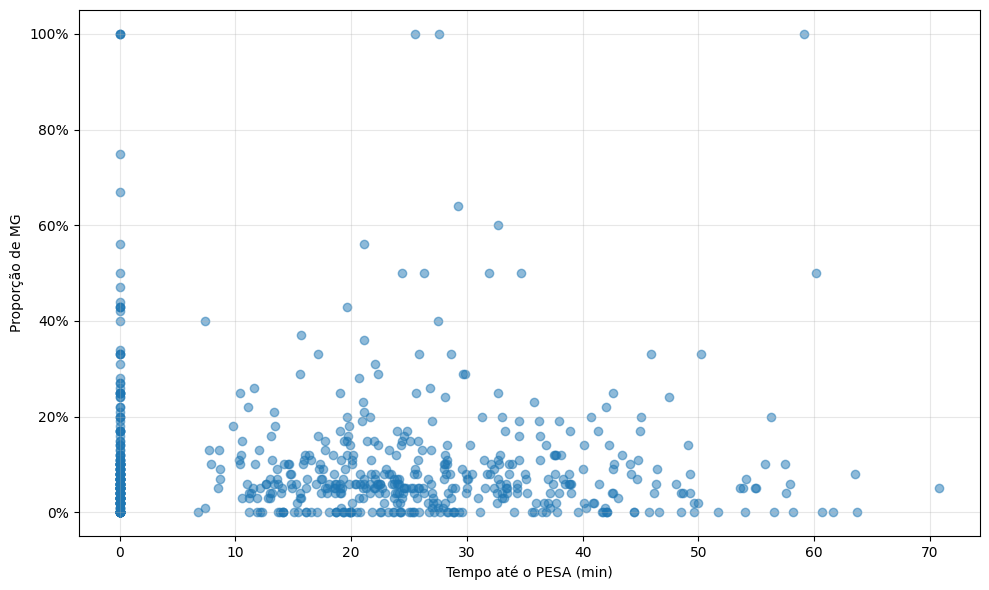

In [46]:
# Tempo × Proporção MG (gráfico principal)

from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(10,6))

plt.scatter(
    df["TEMPO"],
    df["PROP_MG"],
    alpha=0.5
)

plt.xlabel("Tempo até o PESA (min)")
plt.ylabel("Proporção de MG")

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(1)
)

plt.grid(alpha=.3)

plt.tight_layout()
plt.show()

/home/usuario/venvs/datascience/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


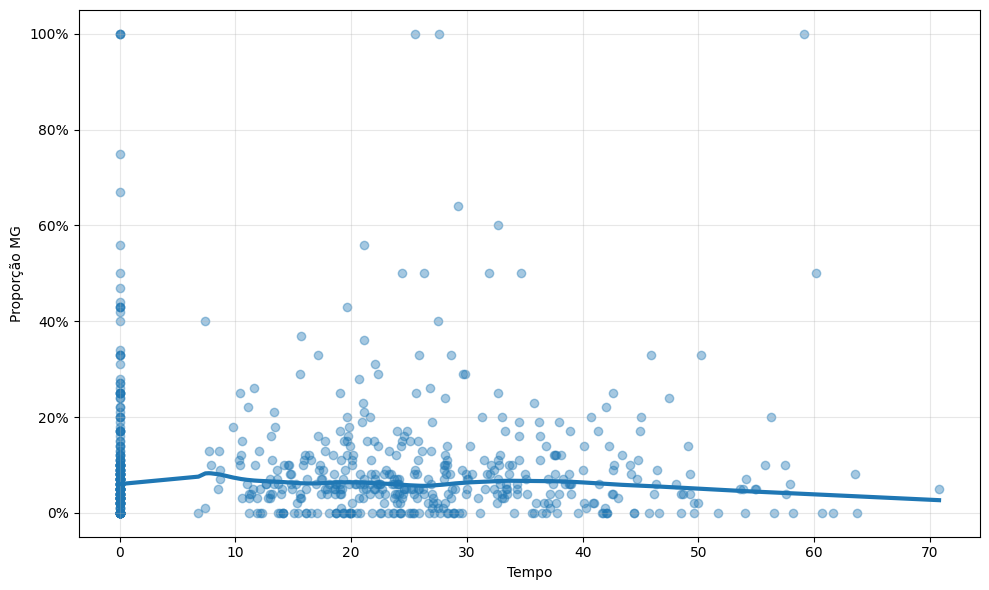

In [ ]:
# LOWESS
from statsmodels.nonparametric.smoothers_lowess import lowess

curva = lowess(
    df["PROP_MG"],
    df["TEMPO"],
    frac=0.3
)

plt.figure(figsize=(10,6))

plt.scatter(
    df["TEMPO"],
    df["PROP_MG"],
    alpha=.4
)

plt.plot(
    curva[:,0],
    curva[:,1],
    linewidth=3
)

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(1)
)

plt.xlabel("Tempo")
plt.ylabel("Proporção MG")

plt.grid(alpha=.3)

plt.tight_layout()


'''Esta figura responde: existe linearidade?'''

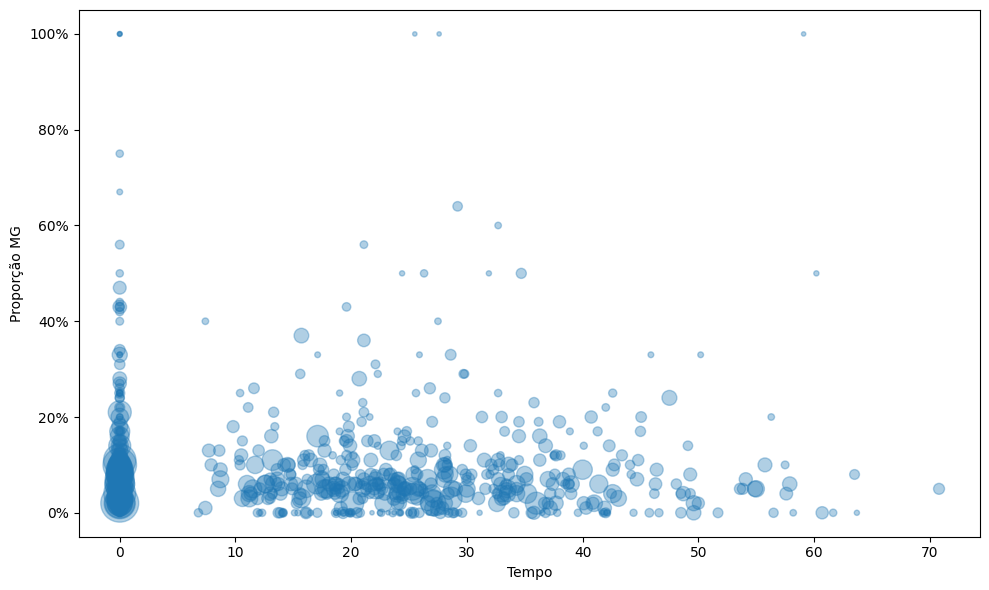

In [ ]:
# Pontos proporcionais ao número de casos

import numpy as np

plt.figure(figsize=(10,6))

plt.scatter(
    df["TEMPO"],
    df["PROP_MG"],
    s=np.sqrt(df["TOTAL_CASOS"])*10,
    alpha=.35
)

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(1)
)

plt.xlabel("Tempo")
plt.ylabel("Proporção MG")

plt.tight_layout()  

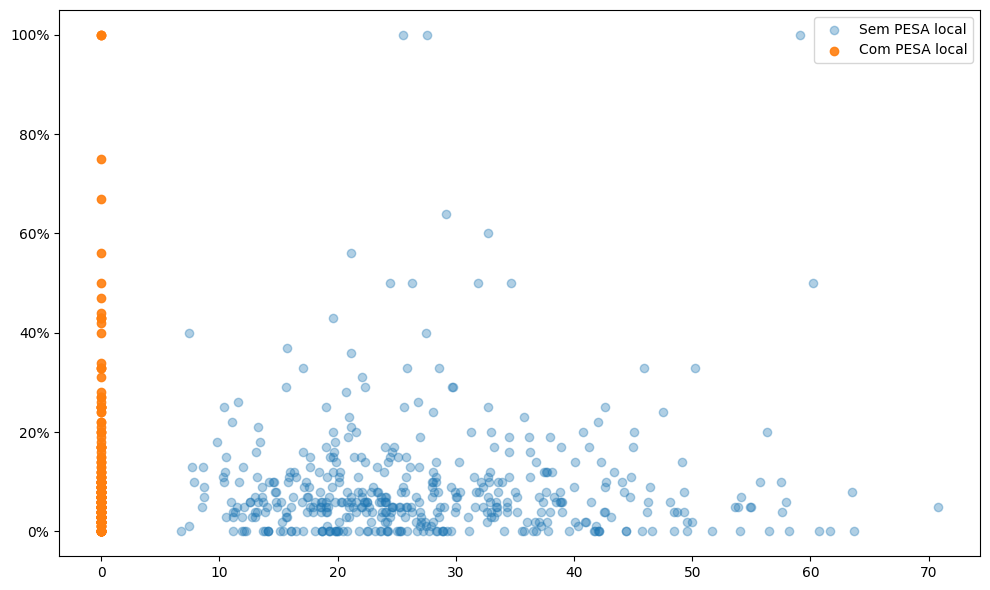

In [49]:
# Municípios com PESA local destacados

local = df["TEMPO"]==0

plt.figure(figsize=(10,6))

plt.scatter(
    df.loc[~local,"TEMPO"],
    df.loc[~local,"PROP_MG"],
    alpha=.35,
    label="Sem PESA local"
)

plt.scatter(
    df.loc[local,"TEMPO"],
    df.loc[local,"PROP_MG"],
    alpha=.9,
    label="Com PESA local"
)

plt.legend()

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(1)
)

plt.tight_layout()

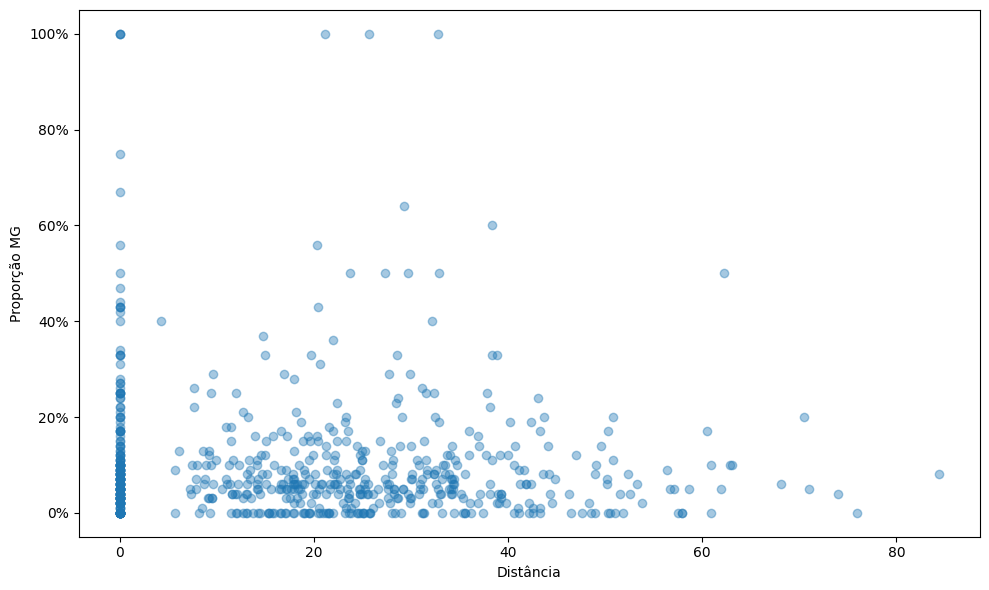

In [50]:
# Distância × Proporção MG

plt.figure(figsize=(10,6))

plt.scatter(
    df["DISTANCIA"],
    df["PROP_MG"],
    alpha=.4
)

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(1)
)

plt.xlabel("Distância")
plt.ylabel("Proporção MG")

plt.tight_layout()

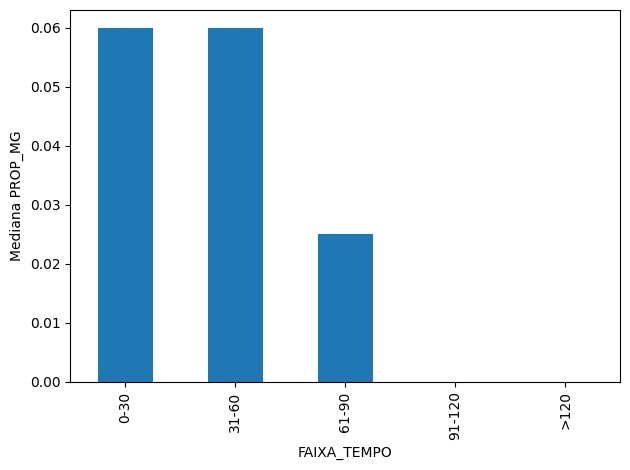

In [51]:
# Tempo categorizado
bins = [0,30,60,90,120,1000]

labels = [
    "0-30",
    "31-60",
    "61-90",
    "91-120",
    ">120"
]

df["FAIXA_TEMPO"] = pd.cut(
    df["TEMPO"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

dados = (
    df
    .groupby("FAIXA_TEMPO", observed=False)["PROP_MG"]
    .median()
)

dados.plot(kind="bar")

plt.ylabel("Mediana PROP_MG")
plt.tight_layout()

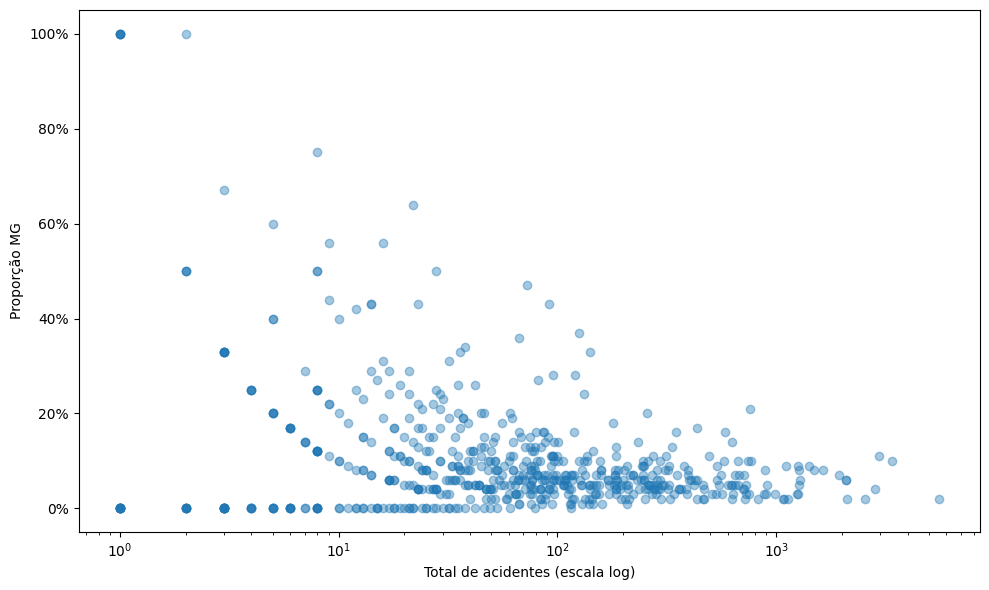

In [52]:
# Prop MG por município

plt.figure(figsize=(10,6))

plt.scatter(
    df["TOTAL_CASOS"],
    df["PROP_MG"],
    alpha=.4
)

plt.xscale("log")

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(1)
)

plt.xlabel("Total de acidentes (escala log)")
plt.ylabel("Proporção MG")

plt.tight_layout()

# Diagnóstico da variável resposta

In [53]:
# Distribuição do denominador

print(df["TOTAL_CASOS"].describe(
    percentiles=[0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]
).round(2))

bins = [0,5,10,20,50,100,250,500,1000]

freq = (
    pd.cut(df["TOTAL_CASOS"], bins=bins)
      .value_counts()
      .sort_index()
      .to_frame("Municípios")
)

freq["%"] = (100*freq["Municípios"]/len(df)).round(1)

display(freq)

count     645.00
mean      181.95
std       413.92
min         0.00
1%          0.00
5%          2.00
10%         5.00
25%        17.00
50%        57.00
75%       158.00
90%       435.20
95%       730.80
99%      2083.24
max      5555.00
Name: TOTAL_CASOS, dtype: float64


,Municípios,%
TOTAL_CASOS,,
"(0, 5]",66,10.2
"(5, 10]",47,7.3
"(10, 20]",54,8.4
"(20, 50]",129,20.0
"(50, 100]",119,18.4
"(100, 250]",106,16.4
"(250, 500]",56,8.7
"(500, 1000]",36,5.6


In [54]:
# Quantos municípios possuem MG=0?
print("Municípios com MG = 0:",
      (df["MG"]==0).sum())

print("%:",
      round(100*(df["MG"]==0).mean(),1))

display(
    df["MG"].value_counts().sort_index().head(20)
)

Municípios com MG = 0: 102
%: 15.8


MG
0     102
1      84
2      66
3      40
4      34
5      40
6      31
7      31
8      14
9      13
10     17
11     22
12      9
13      7
14     16
15      9
16      6
17      4
18      6
19      2
Name: count, dtype: int64

In [56]:
# Distribuição da proporção MG

print(df["PROP_MG"].describe(
    percentiles=[0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]
).round(4))

count    645.0000
mean       0.1020
std        0.1384
min        0.0000
1%         0.0000
5%         0.0000
10%        0.0000
25%        0.0300
50%        0.0600
75%        0.1200
90%        0.2400
95%        0.3300
99%        0.7148
max        1.0000
Name: PROP_MG, dtype: float64


In [57]:
print(
    "PROP_MG = 0:",
    (df["PROP_MG"]==0).sum()
)

print(
    "PROP_MG >0:",
    (df["PROP_MG"]>0).sum()
)

PROP_MG = 0: 102
PROP_MG >0: 543
